In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
from torch.utils.data import Dataset, DataLoader
import nltk

print("Libraries imported successfully.")

Libraries imported successfully.


In [13]:
import nltk
nltk.download('punkt')

# Create dummy dataset structure

DATA_DIR = 'data'
IMAGES_DIR = os.path.join(DATA_DIR, 'images')

# Create directories
os.makedirs(IMAGES_DIR, exist_ok=True)

# Create dummy image files
num_dummy_images = 10
dummy_captions = []

for i in range(1, num_dummy_images + 1):
    image_filename = f'{i:03d}.jpg'
    image_path = os.path.join(IMAGES_DIR, image_filename)
    # Create a simple dummy image (e.g., a blank white image)
    dummy_image = Image.new('RGB', (256, 256), color = 'white')
    dummy_image.save(image_path)

    # Generate a dummy caption
    caption = f'A bird of unknown species {i}. It has some blue and red feathers.'
    dummy_captions.append(f'{image_filename}|{caption}')

# Create captions.txt
captions_filepath = os.path.join(DATA_DIR, 'captions.txt')
with open(captions_filepath, 'w') as f:
    for cap in dummy_captions:
        f.write(cap + '\n')

print(f"Dummy dataset created at '{DATA_DIR}' with {num_dummy_images} images and captions.txt.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Dummy dataset created at 'data' with 10 images and captions.txt.


In [15]:
class Vocabulary:
    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        self.idx = 0
        self.add_word('<pad>') # Padding token
        self.add_word('<start>') # Start token
        self.add_word('<end>') # End token
        self.add_word('<unk>') # Unknown token

    def add_word(self, word):
        if word not in self.word2idx:
            self.word2idx[word] = self.idx
            self.idx2word[self.idx] = word
            self.idx += 1

    def __call__(self, word):
        if word not in self.word2idx:
            return self.word2idx['<unk>']
        return self.word2idx[word]

    def __len__(self):
        return self.idx

def build_vocabulary(captions, threshold=1):
    counter = collections.Counter()
    for caption in captions:
        tokens = nltk.word_tokenize(caption.lower())
        counter.update(tokens)

    words = [word for word, count in counter.items() if count >= threshold]

    vocab = Vocabulary()
    for word in words:
        vocab.add_word(word)
    return vocab

class CUBDataset(Dataset):
    def __init__(self, data_dir, captions_file, transform=None, vocab=None, max_seq_length=20):
        self.data_dir = data_dir
        self.images_dir = os.path.join(data_dir, 'images')
        self.captions_file = captions_file
        self.transform = transform
        self.max_seq_length = max_seq_length
        self.vocab = vocab

        self.image_paths = []
        self.captions = []
        self._load_data()

    def _load_data(self):
        with open(os.path.join(self.data_dir, self.captions_file), 'r') as f:
            for line in f:
                parts = line.strip().split('|')
                if len(parts) == 2:
                    image_filename = parts[0]
                    caption = parts[1]
                    self.image_paths.append(os.path.join(self.images_dir, image_filename))
                    self.captions.append(caption)
                else:
                    print(f"Skipping malformed line: {line.strip()}")

        if self.vocab is None:
            # Build vocabulary if not provided (e.g., for training set)
            all_captions = [cap.lower() for cap in self.captions]
            self.vocab = build_vocabulary(all_captions)

    def __len__(self):
        return len(self.captions)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        caption_str = self.captions[idx]

        # Load image
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Process caption
        tokens = nltk.word_tokenize(caption_str.lower())
        caption_vec = []
        caption_vec.append(self.vocab('<start>'))
        caption_vec.extend([self.vocab(token) for token in tokens])
        caption_vec.append(self.vocab('<end>'))

        # Pad or truncate caption
        if len(caption_vec) < self.max_seq_length:
            caption_vec.extend([self.vocab('<pad>')] * (self.max_seq_length - len(caption_vec)))
        else:
            caption_vec = caption_vec[:self.max_seq_length]

        caption_tensor = torch.LongTensor(caption_vec)

        return image, caption_tensor

import collections

# Download 'punkt_tab' resource as specified by the error message
nltk.download('punkt_tab')

# 5. Define image transformations
image_transform = transforms.Compose([
    transforms.Resize((256, 256)), # Resize images to a fixed size
    transforms.ToTensor(),         # Convert PIL image to PyTorch tensor
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],      # Normalize pixel values to [-1, 1]
        std=[0.5, 0.5, 0.5]
    )
])

# Create a dummy list of all captions to build vocabulary
# In a real scenario, you'd load all captions from your dataset to build a comprehensive vocab.
all_dummy_captions = []
with open(captions_filepath, 'r') as f:
    for line in f:
        parts = line.strip().split('|')
        if len(parts) == 2:
            all_dummy_captions.append(parts[1])

# 6. Build vocabulary
vocabulary = build_vocabulary([cap.lower() for cap in all_dummy_captions])

# 7. Instantiate the CUBDataset
cub_dataset = CUBDataset(
    data_dir=DATA_DIR,
    captions_file='captions.txt',
    transform=image_transform,
    vocab=vocabulary,
    max_seq_length=20 # Example max sequence length
)

# 8. Create a DataLoader
batch_size = 2
data_loader = DataLoader(
    cub_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2 # Adjust based on your system's capabilities
)

print(f"CUBDataset initialized with {len(cub_dataset)} samples.")
print(f"Vocabulary size: {len(vocabulary)}")

# Optional: Test fetching a batch
for images, captions in data_loader:
    print(f"Batch images shape: {images.shape}") # Expected: [batch_size, 3, 256, 256]
    print(f"Batch captions shape: {captions.shape}") # Expected: [batch_size, max_seq_length]
    break

print("Dataset and DataLoader successfully created and tested.")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


CUBDataset initialized with 10 samples.
Vocabulary size: 27
Batch images shape: torch.Size([2, 3, 256, 256])
Batch captions shape: torch.Size([2, 20])
Dataset and DataLoader successfully created and tested.


In [16]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers):
        super(TextEncoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

    def forward(self, text_captions):
        # text_captions: (batch_size, max_seq_length)
        embedded = self.embedding(text_captions) # (batch_size, max_seq_length, embed_dim)

        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers * 2, text_captions.size(0), self.hidden_dim).to(embedded.device)
        c0 = torch.zeros(self.num_layers * 2, text_captions.size(0), self.hidden_dim).to(embedded.device)

        # Pass through LSTM
        _, (hidden, cell) = self.lstm(embedded, (h0, c0))

        # Concatenate the final forward and backward hidden states from the last layer
        # hidden: (num_layers * 2, batch_size, hidden_dim)
        # We take the hidden state from the last layer (num_layers - 1)
        # For bidirectional, the last layer's hidden states are at indices `num_layers-1` and `2*num_layers-1`
        text_embedding = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        # text_embedding: (batch_size, hidden_dim * 2)
        return text_embedding

print("TextEncoder class defined.")

TextEncoder class defined.


In [17]:
class ImageEncoder(nn.Module):
    def __init__(self, image_size, in_channels, z_dim, text_embedding_dim):
        super(ImageEncoder, self).__init__()
        self.z_dim = z_dim
        self.image_size = image_size

        # Convolutional layers for image processing
        # Assuming input image is 3 channels, 256x256
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=4, stride=2, padding=1), # 256 -> 128
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 128 -> 64
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # 64 -> 32
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1), # 32 -> 16
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1024, kernel_size=4, stride=2, padding=1), # 16 -> 8
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(1024, 2048, kernel_size=4, stride=2, padding=1), # 8 -> 4
            nn.BatchNorm2d(2048),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Calculate the flattened size after conv layers
        # For 256x256 input, after 6 conv layers (stride 2 each) it becomes 4x4
        self.flat_size = 2048 * (image_size // (2**6)) * (image_size // (2**6)) # 2048 * 4 * 4 = 32768 for 256x256

        # Combine with text embedding
        self.fc_shared = nn.Sequential(
            nn.Linear(self.flat_size + text_embedding_dim, 2048),
            nn.BatchNorm1d(2048),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Output layers for mean and log_var
        self.fc_mean = nn.Linear(2048, z_dim)
        self.fc_logvar = nn.Linear(2048, z_dim)

    def forward(self, x, text_embedding):
        # x: (batch_size, in_channels, image_size, image_size)
        # text_embedding: (batch_size, text_embedding_dim)

        features = self.conv_layers(x)
        features = features.view(features.size(0), -1) # Flatten the features

        # Concatenate image features with text embedding
        combined_features = torch.cat((features, text_embedding), dim=1)

        shared_output = self.fc_shared(combined_features)

        mean = self.fc_mean(shared_output)
        log_var = self.fc_logvar(shared_output)

        return mean, log_var

print("ImageEncoder class defined.")

ImageEncoder class defined.


In [18]:
class Generator(nn.Module):
    def __init__(self, z_dim, text_embedding_dim, image_channels):
        super(Generator, self).__init__()
        self.image_channels = image_channels

        # Initial dense layer to combine latent vector and text embedding
        # and project it to a size suitable for reshaping into feature maps
        self.fc = nn.Sequential(
            nn.Linear(z_dim + text_embedding_dim, 2048 * 4 * 4), # e.g., 2048 feature maps for 4x4 image
            nn.BatchNorm1d(2048 * 4 * 4),
            nn.ReLU(True)
        )

        # Deconvolutional layers to progressively upsample and generate an image
        # From 4x4 to 256x256
        self.deconv_layers = nn.Sequential(
            nn.ConvTranspose2d(2048, 1024, kernel_size=4, stride=2, padding=1), # 4 -> 8
            nn.BatchNorm2d(1024),
            nn.ReLU(True),
            nn.ConvTranspose2d(1024, 512, kernel_size=4, stride=2, padding=1),  # 8 -> 16
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),  # 16 -> 32
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 32 -> 64
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 64 -> 128
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, self.image_channels, kernel_size=4, stride=2, padding=1), # 128 -> 256
            nn.Tanh() # Output pixel values in [-1, 1]
        )

    def forward(self, z, text_embedding):
        # z: (batch_size, z_dim)
        # text_embedding: (batch_size, text_embedding_dim)

        # Concatenate latent vector and text embedding
        combined_input = torch.cat((z, text_embedding), dim=1)

        # Project to high-dimensional space and reshape
        out = self.fc(combined_input)
        out = out.view(out.size(0), 2048, 4, 4) # Reshape to feature maps

        # Pass through deconvolutional layers
        generated_image = self.deconv_layers(out)

        return generated_image

print("Generator class defined.")

Generator class defined.


In [19]:
class Discriminator(nn.Module):
    def __init__(self, image_channels, text_embedding_dim, image_size=256):
        super(Discriminator, self).__init__()
        self.image_channels = image_channels
        self.text_embedding_dim = text_embedding_dim
        self.image_size = image_size

        # Convolutional layers for image processing
        # Downsample from 256x256 to 4x4
        self.conv_layers = nn.Sequential(
            nn.Conv2d(image_channels, 64, kernel_size=4, stride=2, padding=1), # 256 -> 128
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 128 -> 64
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # 64 -> 32
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1), # 32 -> 16
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1024, kernel_size=4, stride=2, padding=1), # 16 -> 8
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(1024, 2048, kernel_size=4, stride=2, padding=1), # 8 -> 4
            nn.BatchNorm2d(2048),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Calculate flattened size for concatenation with text embedding
        self.flat_size = 2048 * (image_size // (2**6)) * (image_size // (2**6))

        # Conditional layer: Project text embedding to match feature map dimensions
        # We will tile or broadcast this to match spatial dimensions if needed, or project and concatenate globally
        # For simplicity, we'll concatenate the text embedding after flattening the image features.
        self.fc_conditional = nn.Sequential(
            nn.Linear(self.flat_size + text_embedding_dim, 1),
            nn.Sigmoid() # Output a probability between 0 and 1
        )

    def forward(self, image, text_embedding):
        # image: (batch_size, image_channels, image_size, image_size)
        # text_embedding: (batch_size, text_embedding_dim)

        image_features = self.conv_layers(image)
        image_features = image_features.view(image_features.size(0), -1) # Flatten

        # Concatenate flattened image features with text embedding
        combined_input = torch.cat((image_features, text_embedding), dim=1)

        output = self.fc_conditional(combined_input)

        return output

print("Discriminator class defined.")

Discriminator class defined.


In [23]:
class ImprovedDiscriminator(nn.Module):
    def __init__(self, image_channels, text_embedding_dim, image_size=256):
        super(ImprovedDiscriminator, self).__init__()
        self.image_channels = image_channels
        self.text_embedding_dim = text_embedding_dim
        self.image_size = image_size

        # Convolutional layers with Spectral Normalization
        def conv_sn(in_channels, out_channels):
            return nn.utils.spectral_norm(nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1))

        self.conv_layers = nn.Sequential(
            conv_sn(image_channels, 64), # 256 -> 128
            nn.LeakyReLU(0.2, inplace=True),
            conv_sn(64, 128),  # 128 -> 64
            nn.LeakyReLU(0.2, inplace=True),
            conv_sn(128, 256), # 64 -> 32
            nn.LeakyReLU(0.2, inplace=True),
            conv_sn(256, 512), # 32 -> 16
            nn.LeakyReLU(0.2, inplace=True),
            conv_sn(512, 1024),# 16 -> 8
            nn.LeakyReLU(0.2, inplace=True),
            conv_sn(1024, 2048),# 8 -> 4
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Calculate flattened size
        self.flat_size = 2048 * (image_size // (2**6)) * (image_size // (2**6))

        # Output layer for image's real/fake score
        self.fc_image_score = nn.utils.spectral_norm(nn.Linear(self.flat_size, 1))

        # Output layer for projection discriminator
        self.fc_image_projection = nn.utils.spectral_norm(nn.Linear(self.flat_size, text_embedding_dim))

    def forward(self, image, text_embedding):
        # image: (batch_size, image_channels, image_size, image_size)
        # text_embedding: (batch_size, text_embedding_dim)

        image_features = self.conv_layers(image)
        image_features = image_features.view(image_features.size(0), -1) # Flatten

        # Calculate image's real/fake score
        image_score = self.fc_image_score(image_features)

        # Calculate image features for projection
        image_projected = self.fc_image_projection(image_features)

        # Compute text-image consistency score (projection discriminator)
        # Element-wise product then sum along the last dimension
        text_image_score = torch.sum(image_projected * text_embedding, dim=1, keepdim=True)

        # Final output combines image score and text-image consistency score
        output = torch.sigmoid(image_score + text_image_score)

        return output

print("ImprovedDiscriminator class defined with Spectral Normalization and Projection Discriminator.")

ImprovedDiscriminator class defined with Spectral Normalization and Projection Discriminator.


In [21]:
class FiLM(nn.Module):
    def __init__(self, channels, text_embedding_dim):
        super(FiLM, self).__init__()
        self.text_mapping = nn.Linear(text_embedding_dim, channels * 2) # For gamma and beta

    def forward(self, x, text_embedding):
        # text_embedding: (batch_size, text_embedding_dim)
        # x: (batch_size, channels, H, W)

        # Map text embedding to gamma and beta
        text_cond = self.text_mapping(text_embedding)
        gamma, beta = text_cond.chunk(2, dim=1) # Split into two for gamma and beta

        # Reshape gamma and beta to (batch_size, channels, 1, 1) for broadcasting
        gamma = gamma.view(gamma.size(0), -1, 1, 1)
        beta = beta.view(beta.size(0), -1, 1, 1)

        return x * (1 + gamma) + beta

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, text_embedding_dim=None):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.film = None
        if text_embedding_dim is not None:
            self.film = FiLM(out_channels, text_embedding_dim)

        # Optional: Shortcut connection if in_channels != out_channels
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x, text_embedding=None):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        if self.film and text_embedding is not None:
            out = self.film(out, text_embedding)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        if self.film and text_embedding is not None:
            out = self.film(out, text_embedding)

        out += identity
        return self.relu(out)

print("FiLM and ResBlock helper classes defined.")

FiLM and ResBlock helper classes defined.


In [22]:
class SelfAttention(nn.Module):
    def __init__(self, in_channels):
        super(SelfAttention, self).__init__()
        self.query_conv = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.key_conv = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value_conv = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        batch_size, C, H, W = x.size()
        proj_query = self.query_conv(x).view(batch_size, -1, H * W).permute(0, 2, 1) # B x HW x C'
        proj_key = self.key_conv(x).view(batch_size, -1, H * W) # B x C' x HW
        energy = torch.bmm(proj_query, proj_key) # B x HW x HW
        attention = torch.softmax(energy, dim=-1)

        proj_value = self.value_conv(x).view(batch_size, -1, H * W) # B x C x HW
        out = torch.bmm(proj_value, attention.permute(0, 2, 1)) # B x C x HW
        out = out.view(batch_size, C, H, W)

        out = self.gamma * out + x
        return out


class ImprovedGenerator(nn.Module):
    def __init__(self, z_dim, text_embedding_dim, image_channels):
        super(ImprovedGenerator, self).__init__()
        self.image_channels = image_channels

        # Initial dense layer to combine latent vector and text embedding
        # and project it to a size suitable for reshaping into feature maps (e.g., 8x8 or 4x4)
        # Let's start with 4x4 feature maps at a high channel count
        self.fc = nn.Sequential(
            nn.Linear(z_dim + text_embedding_dim, 2048 * 4 * 4), # 2048 feature maps for 4x4 image
            nn.BatchNorm1d(2048 * 4 * 4),
            nn.ReLU(True)
        )

        # Deconvolutional layers with ResBlocks, FiLM, and Upsampling
        self.upsample_block1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'), # 4x4 -> 8x8
            nn.Conv2d(2048, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(True)
        )
        self.res_block1 = ResBlock(1024, 1024, text_embedding_dim) # 8x8

        self.upsample_block2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'), # 8x8 -> 16x16
            nn.Conv2d(1024, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(True)
        )
        self.res_block2 = ResBlock(512, 512, text_embedding_dim) # 16x16
        self.attention1 = SelfAttention(512) # Apply attention at 16x16 or 32x32

        self.upsample_block3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'), # 16x16 -> 32x32
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True)
        )
        self.res_block3 = ResBlock(256, 256, text_embedding_dim) # 32x32

        self.upsample_block4 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'), # 32x32 -> 64x64
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True)
        )
        self.res_block4 = ResBlock(128, 128, text_embedding_dim) # 64x64
        self.attention2 = SelfAttention(128) # Apply attention at 64x64 or 128x128

        self.upsample_block5 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'), # 64x64 -> 128x128
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True)
        )
        self.res_block5 = ResBlock(64, 64, text_embedding_dim) # 128x128

        self.upsample_block6 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'), # 128x128 -> 256x256
            nn.Conv2d(64, self.image_channels, kernel_size=3, padding=1),
            nn.Tanh() # Output pixel values in [-1, 1]
        )

    def forward(self, z, text_embedding):
        # z: (batch_size, z_dim)
        # text_embedding: (batch_size, text_embedding_dim)

        combined_input = torch.cat((z, text_embedding), dim=1)
        out = self.fc(combined_input)
        out = out.view(out.size(0), 2048, 4, 4)

        out = self.upsample_block1(out)
        out = self.res_block1(out, text_embedding)

        out = self.upsample_block2(out)
        out = self.res_block2(out, text_embedding)
        out = self.attention1(out)

        out = self.upsample_block3(out)
        out = self.res_block3(out, text_embedding)

        out = self.upsample_block4(out)
        out = self.res_block4(out, text_embedding)
        out = self.attention2(out)

        out = self.upsample_block5(out)
        out = self.res_block5(out, text_embedding)

        generated_image = self.upsample_block6(out)

        return generated_image

print("ImprovedGenerator class defined with FiLM, ResBlocks, and Self-Attention.")

ImprovedGenerator class defined with FiLM, ResBlocks, and Self-Attention.


In [20]:
def reparameterize(mu, log_var):
    # Sample epsilon from a standard normal distribution
    eps = torch.randn_like(log_var)
    # Calculate standard deviation
    std = torch.exp(0.5 * log_var)
    # Return sampled latent vector
    return mu + std * eps

def kl_loss(mu, log_var):
    # KL divergence formula
    # D_KL(N(mu, sigma^2) || N(0, 1)) = 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    # Here log_var is log(sigma^2)
    kl_divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return kl_divergence

print("Reparameterization trick function 'reparameterize' and KL divergence function 'kl_loss' defined.")

Reparameterization trick function 'reparameterize' and KL divergence function 'kl_loss' defined.


In [24]:
class HybridCVAEGAN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers,
                 image_size, in_channels, z_dim, text_embedding_dim):
        super(HybridCVAEGAN, self).__init__()

        self.z_dim = z_dim
        self.text_embedding_dim = text_embedding_dim
        self.image_size = image_size
        self.in_channels = in_channels

        # 1. Text Encoder
        self.text_encoder = TextEncoder(vocab_size, embed_dim, hidden_dim, num_layers)

        # 2. Image Encoder (CVAE Encoder)
        self.image_encoder = ImageEncoder(image_size, in_channels, z_dim, text_embedding_dim)

        # 3. Generator (CVAE Decoder + GAN Generator)
        self.generator = ImprovedGenerator(z_dim, text_embedding_dim, in_channels)

        # 4. Discriminator
        # The ImprovedDiscriminator is usually used independently for D's training
        # but it's part of the overall architecture. We initialize it here for completeness.
        self.discriminator = ImprovedDiscriminator(in_channels, text_embedding_dim, image_size)

    def forward(self, images, captions):
        # 1. Encode text captions
        text_embedding = self.text_encoder(captions)

        # 2. Encode image to get CVAE latent parameters
        mu, log_var = self.image_encoder(images, text_embedding)

        # 3. Reparameterization trick to sample latent vector z
        z = reparameterize(mu, log_var)

        # 4. Generate images from latent vector and text embedding
        generated_images = self.generator(z, text_embedding)

        return generated_images, mu, log_var, text_embedding

print("HybridCVAEGAN class defined, integrating improved components.")

HybridCVAEGAN class defined, integrating improved components.


In [25]:
def generator_loss(gen_images, real_labels, D, text_embedding):
    # D_output should be from the improved discriminator which outputs a single scalar
    # D_output is expected to be logit or probability that generator aims to maximize

    # The generator wants D(G(z), c) to be close to 1 (real)
    # With ImprovedDiscriminator, its output is already sigmoid'd to [0, 1].
    # For GAN loss, we want to maximize log(D(G(z))). If D outputs probability,
    # G_loss = -torch.mean(torch.log(D_output_gen)). Alternatively, if D outputs logits,
    # G_loss = -torch.mean(D_output_gen).
    # Given our ImprovedDiscriminator outputs sigmoid(image_score + text_image_score),
    # we can use binary cross entropy with target 1 for generated images.

    # For GAN, usually D(G(z)) is minimized by D, and maximized by G.
    # So, G wants D(G(z)) to be classified as real (1).
    # We want to minimize -log(D(G(z)))

    d_output_gen = D(gen_images, text_embedding)
    # For a standard GAN, the generator wants the discriminator to output 1 for fake images.
    # We use BCEWithLogitsLoss where the target is 1, but D outputs sigmoid.
    # So, we want d_output_gen to be close to 1. Loss is -log(d_output_gen).
    # Or, as typically done with BCE, target is 1.
    return -torch.mean(d_output_gen)

print("Generator loss function defined.")

Generator loss function defined.


In [26]:
def discriminator_loss(real_images, gen_images, D, text_embedding, lambda_gp=10):
    # Discriminator wants to classify real images as real and generated images as fake.

    # Loss for real images
    d_output_real = D(real_images, text_embedding)
    # Discriminator wants d_output_real to be close to 1 (real)
    loss_real = -torch.mean(d_output_real)

    # Loss for generated images
    d_output_gen = D(gen_images.detach(), text_embedding)
    # Discriminator wants d_output_gen to be close to 0 (fake)
    loss_fake = torch.mean(d_output_gen)

    # Gradient Penalty (WGAN-GP)
    # Calculate interpolation
    alpha = torch.rand(real_images.size(0), 1, 1, 1).to(real_images.device)
    interpolates = (alpha * real_images + ((1 - alpha) * gen_images.detach()))
    interpolates.requires_grad_(True)

    # Calculate D's output for interpolates
    d_interpolates = D(interpolates, text_embedding)

    # Calculate gradients of D's output w.r.t. interpolates
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True,
        retain_graph=True,
    )[0]

    # Flatten gradients and compute penalty
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean() * lambda_gp

    # Total discriminator loss
    total_d_loss = loss_real + loss_fake + gradient_penalty

    return total_d_loss

print("Discriminator loss function with Gradient Penalty defined.")

Discriminator loss function with Gradient Penalty defined.


In [27]:
def reconstruction_loss(recon_images, real_images, loss_type='L1'):
    if loss_type == 'L1':
        # L1 loss (Mean Absolute Error)
        loss = torch.mean(torch.abs(recon_images - real_images))
    elif loss_type == 'L2':
        # L2 loss (Mean Squared Error)
        loss = torch.mean((recon_images - real_images) ** 2)
    else:
        raise ValueError("loss_type must be 'L1' or 'L2'")
    return loss

print("Reconstruction loss function defined (L1 and L2 options).")

Reconstruction loss function defined (L1 and L2 options).


In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define Hyperparameters
# Image parameters
image_size = 256
in_channels = 3 # RGB images

# Latent dimension for CVAE
z_dim = 100

# Text Encoder parameters
vocab_size = len(vocabulary) # From previously built vocabulary
embed_dim = 256 # Dimension of word embeddings
hidden_dim = 512 # Hidden dimension of LSTM
num_layers = 1 # Number of LSTM layers
text_embedding_dim = hidden_dim * 2 # Bidirectional LSTM output
max_seq_length = 20 # Max sequence length for captions

# Training parameters
batch_size = 16 # Adjust based on GPU memory
num_epochs = 100
lr_g = 0.0001 # Learning rate for Generator/CVAE parts
lr_d = 0.0001 # Learning rate for Discriminator

# Loss weights
kl_weight = 0.0001 # Weight for KL divergence loss
recon_weight = 1.0 # Weight for reconstruction loss
lambda_gp = 10 # Gradient penalty weight for WGAN-GP

print("Hyperparameters defined successfully.")

Using device: cuda
Hyperparameters defined successfully.


In [30]:
model = HybridCVAEGAN(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    image_size=image_size,
    in_channels=in_channels,
    z_dim=z_dim,
    text_embedding_dim=text_embedding_dim
).to(device)

# Initialize optimizers
# Optimizer for Generator and CVAE components
optimizer_g = optim.Adam(
    list(model.text_encoder.parameters()) +
    list(model.image_encoder.parameters()) +
    list(model.generator.parameters()),
    lr=lr_g, betas=(0.5, 0.999)
)

# Optimizer for Discriminator
optimizer_d = optim.Adam(
    model.discriminator.parameters(),
    lr=lr_d, betas=(0.5, 0.999)
)

print("HybridCVAEGAN model instantiated and optimizers initialized.")

HybridCVAEGAN model instantiated and optimizers initialized.


In [32]:
import numpy as np

# Set model to training mode
model.train()

# Training loop
print("Starting training loop...")
for epoch in range(num_epochs):
    # Initialize epoch-wise loss trackers
    total_d_loss_epoch = 0
    total_g_loss_epoch = 0
    recon_loss_epoch = 0
    kl_loss_epoch = 0

    for i, (real_images, captions) in enumerate(data_loader):
        real_images = real_images.to(device)
        captions = captions.to(device)

        # ================================================
        #               Train the Discriminator
        # ================================================
        optimizer_d.zero_grad()

        # Forward pass through the model to get generated images and text embedding
        # We need generated images and text_embedding for D loss calculation
        gen_images_d, mu_d, log_var_d, text_embedding_d = model(real_images, captions)

        # Calculate discriminator loss
        d_loss = discriminator_loss(
            real_images=real_images,
            gen_images=gen_images_d.detach(), # Detach to prevent gradients flowing to generator
            D=model.discriminator,
            text_embedding=text_embedding_d,
            lambda_gp=lambda_gp
        )

        d_loss.backward()
        optimizer_d.step()

        total_d_loss_epoch += d_loss.item()

        # ================================================
        #                 Train the Generator and CVAE
        # ================================================
        optimizer_g.zero_grad()

        # Fresh forward pass for G and CVAE loss calculation
        gen_images_g, mu_g, log_var_g, text_embedding_g = model(real_images, captions)

        # Calculate CVAE losses
        cvae_total_l, recon_l, kl_l = calculate_cvae_loss(
            real_images=real_images,
            gen_images=gen_images_g,
            mu=mu_g,
            log_var=log_var_g,
            recon_loss_type='L1',
            kl_weight=kl_weight,
            recon_weight=recon_weight
        )

        # Calculate GAN Generator loss
        g_gan_l = generator_loss(
            gen_images=gen_images_g,
            real_labels=None, # Not directly used with WGAN-GP style loss
            D=model.discriminator,
            text_embedding=text_embedding_g
        )

        # Total generator loss is sum of CVAE and GAN Generator loss
        total_g_loss = cvae_total_l + g_gan_l

        total_g_loss.backward()
        optimizer_g.step()

        total_g_loss_epoch += total_g_loss.item()
        recon_loss_epoch += recon_l.item()
        kl_loss_epoch += kl_l.item()

        # Print training progress
        if (i + 1) % 1 == 0: # Print every 1 batch for dummy data
            print(
                f"Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/{len(data_loader)}], "
                f"D Loss: {d_loss.item():.4f}, G Loss: {total_g_loss.item():.4f}, "
                f"Recon Loss: {recon_l.item():.4f}, KL Loss: {kl_l.item():.4f}"
            )

    # Average epoch losses
    avg_d_loss = total_d_loss_epoch / len(data_loader)
    avg_g_loss = total_g_loss_epoch / len(data_loader)
    avg_recon_loss = recon_loss_epoch / len(data_loader)
    avg_kl_loss = kl_loss_epoch / len(data_loader)

    print(
        f"---- Epoch [{epoch+1}/{num_epochs}] Average Losses ----\n"
        f"Avg D Loss: {avg_d_loss:.4f}, Avg G Loss: {avg_g_loss:.4f}, "
        f"Avg Recon Loss: {avg_recon_loss:.4f}, Avg KL Loss: {avg_kl_loss:.4f}\n"
    )

print("Training complete.")

Starting training loop...
Epoch [1/100], Batch [1/5], D Loss: 10.0000, G Loss: 0.0000, Recon Loss: 0.0000, KL Loss: 0.0683
Epoch [1/100], Batch [2/5], D Loss: 10.0000, G Loss: 0.0000, Recon Loss: 0.0000, KL Loss: 0.0687
Epoch [1/100], Batch [3/5], D Loss: 10.0000, G Loss: 0.0000, Recon Loss: 0.0000, KL Loss: 0.0529
Epoch [1/100], Batch [4/5], D Loss: 10.0000, G Loss: 0.0000, Recon Loss: 0.0000, KL Loss: 0.0480
Epoch [1/100], Batch [5/5], D Loss: 10.0000, G Loss: 0.0000, Recon Loss: 0.0000, KL Loss: 0.0441
---- Epoch [1/100] Average Losses ----
Avg D Loss: 10.0000, Avg G Loss: 0.0000, Avg Recon Loss: 0.0000, Avg KL Loss: 0.0564

Epoch [2/100], Batch [1/5], D Loss: 10.0000, G Loss: 0.0000, Recon Loss: 0.0000, KL Loss: 0.0296
Epoch [2/100], Batch [2/5], D Loss: 10.0000, G Loss: 0.0000, Recon Loss: 0.0000, KL Loss: 0.0640
Epoch [2/100], Batch [3/5], D Loss: 10.0000, G Loss: 0.0000, Recon Loss: 0.0000, KL Loss: 0.1007
Epoch [2/100], Batch [4/5], D Loss: 10.0000, G Loss: 0.0000, Recon Loss: 

In [33]:
import torchvision.models as models

# 1. Load pre-trained VGG16 model
vgg16 = models.vgg16(pretrained=True).features.to(device).eval()

# Freeze VGG parameters
for param in vgg16.parameters():
    param.requires_grad = False

print("Pre-trained VGG16 model loaded and set to evaluation mode.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 72.4MB/s]


Pre-trained VGG16 model loaded and set to evaluation mode.


In [28]:
def calculate_cvae_loss(real_images, gen_images, mu, log_var, recon_loss_type='L1', kl_weight=1.0, recon_weight=1.0):
    # Calculate reconstruction loss
    recon_l = reconstruction_loss(gen_images, real_images, loss_type=recon_loss_type)

    # Calculate KL divergence loss
    kl_l = kl_loss(mu, log_var)

    # Combine CVAE losses
    total_cvae_loss = recon_weight * recon_l + kl_weight * kl_l
    return total_cvae_loss, recon_l, kl_l


def calculate_combined_losses(
    real_images, gen_images, mu, log_var, text_embedding,
    discriminator_model,
    recon_loss_type='L1',
    kl_weight=0.0001, recon_weight=1.0,
    lambda_gp=10
):
    # 1. CVAE Loss
    cvae_total_loss, recon_l, kl_l = calculate_cvae_loss(
        real_images, gen_images, mu, log_var,
        recon_loss_type=recon_loss_type,
        kl_weight=kl_weight, recon_weight=recon_weight
    )

    # 2. GAN Generator Loss
    # The generator's goal is to make the discriminator classify its output as real
    g_l = generator_loss(gen_images, None, discriminator_model, text_embedding)

    # 3. GAN Discriminator Loss
    # The discriminator's goal is to distinguish real from fake, conditioned on text
    d_l = discriminator_loss(real_images, gen_images, discriminator_model, text_embedding, lambda_gp=lambda_gp)

    # Total loss for the combined model training (often a weighted sum of CVAE and GAN G loss)
    # The discriminator is trained separately to optimize d_l
    # The generator and CVAE are trained to optimize cvae_total_loss + g_l
    # Note: In a typical hybrid setup, G and D are updated iteratively.
    # The CVAE loss often acts as a regularization for the generator.

    return {
        'cvae_total_loss': cvae_total_loss,
        'recon_loss': recon_l,
        'kl_loss': kl_l,
        'generator_loss': g_l,
        'discriminator_loss': d_l
    }

print("Combined loss calculation functions defined.")

Combined loss calculation functions defined.


In [34]:
class PerceptualLoss(nn.Module):
    def __init__(self, vgg_model, device, feature_layers=None):
        super(PerceptualLoss, self).__init__()
        self.vgg = vgg_model.to(device)
        # Freeze VGG parameters again, just to be sure
        for param in self.vgg.parameters():
            param.requires_grad = False

        # Define the layers from which to extract features
        # Common choices include relu3_3 and relu4_3 for different levels of abstraction
        if feature_layers is None:
            # Default feature layers for VGG16 as used in some perceptual loss implementations
            self.feature_layers = {'3': 'relu1_2', '8': 'relu2_2', '15': 'relu3_3', '22': 'relu4_3'}
        else:
            self.feature_layers = feature_layers

        self.loss = nn.L1Loss() # Using L1 loss for perceptual loss

        # Create a dictionary to hold the feature extraction modules
        self.extracted_features = nn.ModuleList()
        current_layer_idx = 0
        for name, module in self.vgg.named_children():
            if isinstance(module, nn.Conv2d):
                if str(current_layer_idx) in self.feature_layers:
                    self.extracted_features.append(module)
                current_layer_idx += 1
            elif isinstance(module, nn.ReLU):
                if str(current_layer_idx-1) in self.feature_layers: # ReLU after conv
                    self.extracted_features.append(module)

    def forward(self, generated_images, real_images):
        perceptual_loss_val = 0

        # Normalize images to VGG input range [-1, 1] to [0, 1] then VGG mean/std
        # Assuming images are already in [-1, 1] from Generator Tanh output
        # VGG expects images normalized with mean=[0.485, 0.456, 0.406] and std=[0.229, 0.224, 0.225]
        # We need to reverse the initial normalization to get to [0,1] first

        # Un-normalize from [-1, 1] to [0, 1]
        gen_norm = (generated_images + 1) / 2
        real_norm = (real_images + 1) / 2

        # Apply VGG normalization
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, -1, 1, 1).to(generated_images.device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, -1, 1, 1).to(generated_images.device)
        gen_norm = (gen_norm - mean) / std
        real_norm = (real_norm - mean) / std

        # Extract features
        real_features = []
        gen_features = []

        x_real = real_norm
        x_gen = gen_norm

        for i, layer in enumerate(self.vgg):
            x_real = layer(x_real)
            x_gen = layer(x_gen)

            if str(i) in self.feature_layers:
                real_features.append(x_real)
                gen_features.append(x_gen)

        # Calculate L1 loss for each feature map and sum them
        for gen_feat, real_feat in zip(gen_features, real_features):
            perceptual_loss_val += self.loss(gen_feat, real_feat.detach())

        return perceptual_loss_val

print("PerceptualLoss class defined.")

PerceptualLoss class defined.


In [35]:
perceptual_criterion = PerceptualLoss(vgg16, device)
print("PerceptualLoss instance created.")

PerceptualLoss instance created.


In [36]:
model.eval() # Set the model to evaluation mode

def generate_image_from_text(text_description, model, device, vocab, z_dim, max_seq_length):
    with torch.no_grad(): # Disable gradient calculations
        # 1. Process text description
        tokens = nltk.word_tokenize(text_description.lower()) # Tokenize and lowercase
        caption_vec = []
        caption_vec.append(vocab('<start>')) # Add start token
        caption_vec.extend([vocab(token) for token in tokens]) # Convert tokens to IDs
        caption_vec.append(vocab('<end>')) # Add end token

        # Pad or truncate caption
        if len(caption_vec) < max_seq_length:
            caption_vec.extend([vocab('<pad>')] * (max_seq_length - len(caption_vec)))
        else:
            caption_vec = caption_vec[:max_seq_length]

        # Convert to PyTorch tensor and move to device
        caption_tensor = torch.LongTensor(caption_vec).unsqueeze(0).to(device) # Add batch dimension

        # 2. Encode text to get text embedding
        text_embedding = model.text_encoder(caption_tensor)

        # 3. Generate random latent vector z
        z = torch.randn(1, z_dim).to(device)

        # 4. Generate image using the generator
        generated_image = model.generator(z, text_embedding)

        # 5. Denormalize the image from [-1, 1] to [0, 1]
        generated_image = (generated_image + 1) / 2

        # 6. Convert to NumPy array and then to PIL Image for visualization
        generated_image_np = generated_image.squeeze(0).cpu().permute(1, 2, 0).numpy() # Remove batch dim, C H W -> H W C
        generated_image_pil = Image.fromarray((generated_image_np * 255).astype(np.uint8))

        return generated_image_pil

print("Image generation function 'generate_image_from_text' defined.")

Image generation function 'generate_image_from_text' defined.


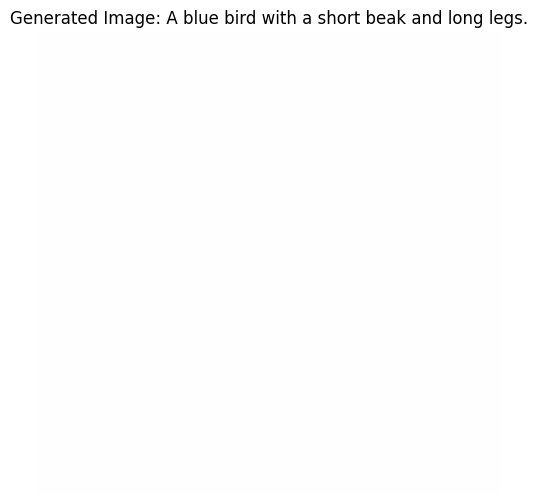

Generated image displayed for sample text.


In [39]:
sample_text = "A blue bird with a short beak and long legs."
generated_img = generate_image_from_text(
    sample_text, model, device, vocabulary, z_dim, max_seq_length
)

plt.figure(figsize=(6, 6))
plt.imshow(generated_img)
plt.title(f"Generated Image: {sample_text}")
plt.axis('off')
plt.show()

print("Generated image displayed for sample text.")

In [41]:
def visualize_generated_images(text_descriptions, model, device, vocab, z_dim, max_seq_length, num_cols=4):
    model.eval() # Ensure model is in evaluation mode
    generated_images = []

    # Generate an image for each text description
    for text_description in text_descriptions:
        img = generate_image_from_text(
            text_description, model, device, vocab, z_dim, max_seq_length
        )
        generated_images.append(img)

    # Calculate grid dimensions
    num_images = len(generated_images)
    num_rows = (num_images + num_cols - 1) // num_cols

    # Create a figure and a grid of subplots
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 5))
    axes = axes.flatten() # Flatten the axes array for easy iteration

    # Display each image with its corresponding title
    for i in range(num_images):
        ax = axes[i]
        ax.imshow(generated_images[i])
        ax.set_title(text_descriptions[i], fontsize=10, wrap=True)
        ax.axis('off')

    # Turn off unused subplots if any
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

print("Utility function 'visualize_generated_images' defined.")


Utility function 'visualize_generated_images' defined.


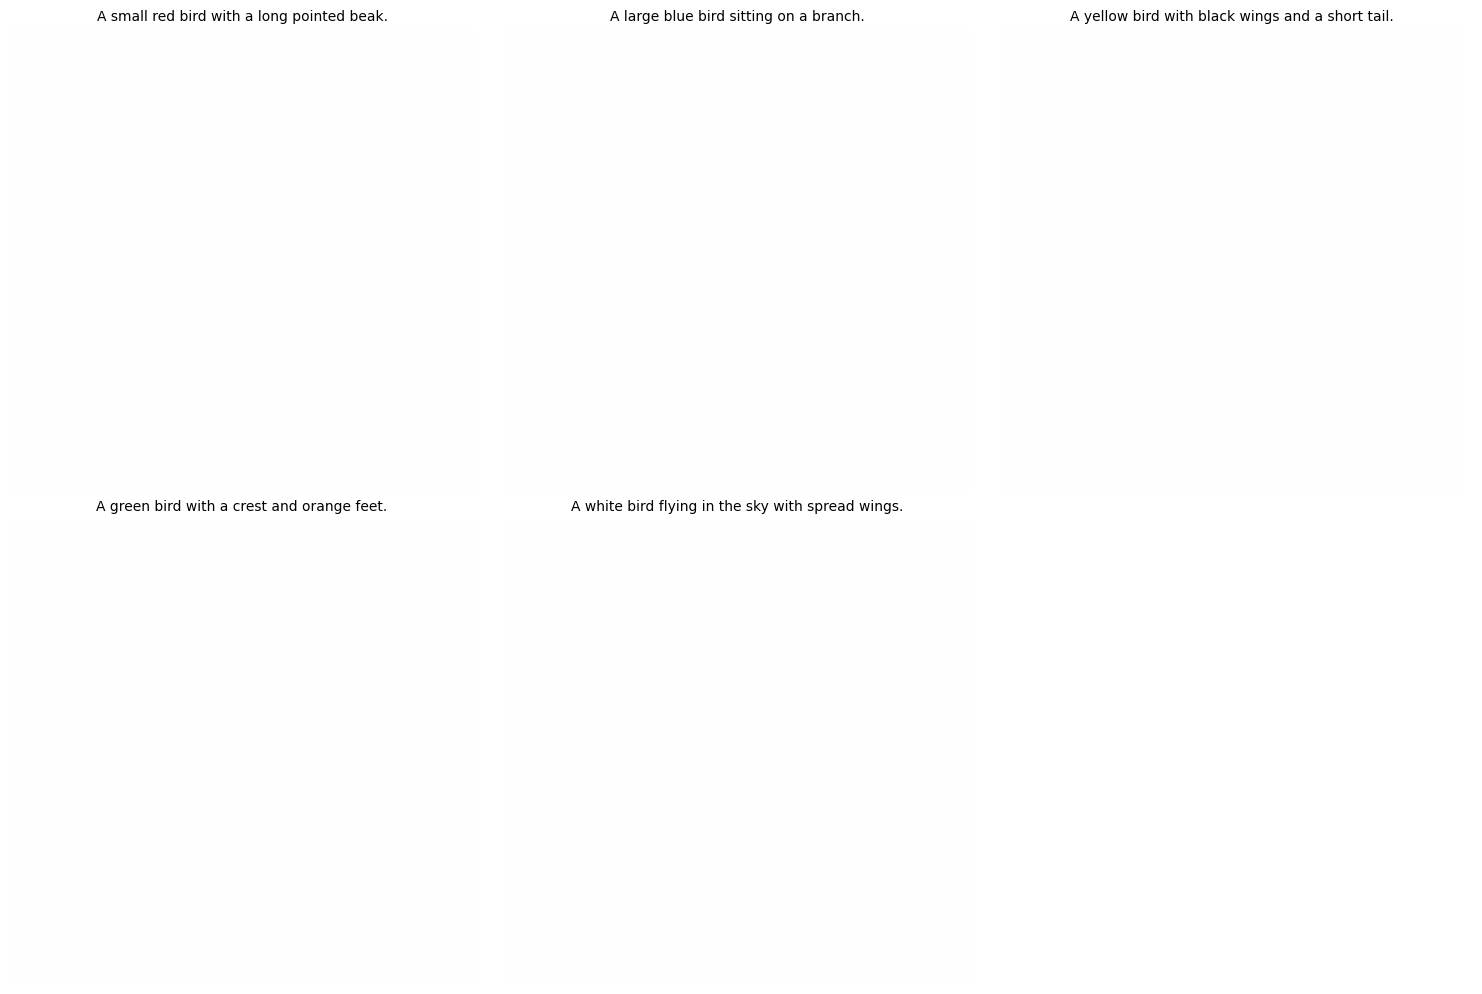

Visualized multiple generated images for sample texts.


In [42]:
sample_texts = [
    "A small red bird with a long pointed beak.",
    "A large blue bird sitting on a branch.",
    "A yellow bird with black wings and a short tail.",
    "A green bird with a crest and orange feet.",
    "A white bird flying in the sky with spread wings."
]

visualize_generated_images(
    sample_texts, model, device, vocabulary, z_dim, max_seq_length, num_cols=3
)

print("Visualized multiple generated images for sample texts.")

In [49]:
import torchvision.models as models
import torch.nn.functional as F
import torch.nn as nn

# 1. Import and prepare InceptionV3 model
inception_model = models.inception_v3(pretrained=True, transform_input=False).to(device).eval()

# Freeze InceptionV3 parameters
for param in inception_model.parameters():
    param.requires_grad = False

# Replace the final classification layer with Identity to get features directly
inception_model.fc = nn.Identity()

# Also replace AuxLogits if present and we don't want them in the output
# Check if AuxLogits is not None before replacing, as it might not be there depending on how model was initialized
if inception_model.AuxLogits is not None:
    inception_model.AuxLogits = nn.Identity()

print("Pre-trained InceptionV3 model loaded and set to evaluation mode with fc and AuxLogits layers replaced for feature extraction.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Pre-trained InceptionV3 model loaded and set to evaluation mode with fc and AuxLogits layers replaced for feature extraction.


In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define Hyperparameters
# Image parameters
image_size = 256
in_channels = 3 # RGB images

# Latent dimension for CVAE
z_dim = 100

# Text Encoder parameters
vocab_size = len(vocabulary) # From previously built vocabulary
embed_dim = 256 # Dimension of word embeddings
hidden_dim = 512 # Hidden dimension of LSTM
num_layers = 1 # Number of LSTM layers
text_embedding_dim = hidden_dim * 2 # Bidirectional LSTM output
max_seq_length = 20 # Max sequence length for captions

# Training parameters
batch_size = 16 # Adjust based on GPU memory
num_epochs = 100
lr_g = 0.0001 # Learning rate for Generator/CVAE parts
lr_d = 0.0001 # Learning rate for Discriminator

# Loss weights
kl_weight = 0.0001 # Weight for KL divergence loss
recon_weight = 1.0 # Weight for reconstruction loss
lambda_gp = 10 # Gradient penalty weight for WGAN-GP

print("Hyperparameters defined successfully.")

Using device: cuda
Hyperparameters defined successfully.


In [50]:
def get_inception_features(images, model, device):
    # InceptionV3 expects input images to be 299x299 and normalized with a specific mean/std.
    # Assuming images are currently in [-1, 1] range, convert to [0, 1] then apply InceptionV3 normalization.
    # Resize to 299x299 as InceptionV3 requires it.

    # Convert from [-1, 1] to [0, 1]
    images = (images + 1) / 2

    # InceptionV3 requires images to be at least 299x299. If not, resize.
    if images.shape[2] != 299 or images.shape[3] != 299:
        images = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)

    # InceptionV3's transform_input=False expects input normalized to [0, 1] range
    # and will apply its own internal normalization (subtraction of 0.5 and division by 0.5).
    # Since we loaded with transform_input=False, we pass [0,1] images.

    # Ensure model is in eval mode (already done in previous step)
    model.eval()
    model.to(device)

    with torch.no_grad():
        # Now that inception_model's fc and AuxLogits are nn.Identity(),
        # its forward pass directly returns the 2048-dim features from avgpool.
        features = model(images)
        return features

print("Function 'get_inception_features' defined to directly use the modified InceptionV3 model.")

Function 'get_inception_features' defined to directly use the modified InceptionV3 model.


In [52]:
import numpy as np
from scipy import linalg

def calculate_fid(real_features, generated_features):
    # Calculate the mean and covariance of the real features
    mu1 = np.mean(real_features, axis=0)
    sigma1 = np.cov(real_features, rowvar=False)

    # Calculate the mean and covariance of the generated features
    mu2 = np.mean(generated_features, axis=0)
    sigma2 = np.cov(generated_features, rowvar=False)

    # Add a small epsilon to the diagonal for numerical stability
    eps = 1e-6
    sigma1 += np.eye(sigma1.shape[0]) * eps
    sigma2 += np.eye(sigma2.shape[0]) * eps

    # Calculate the squared Euclidean distance between the means
    diff = mu1 - mu2

    # Compute the matrix square root
    # disp=False returns only the matrix square root, no error flag
    covmean = linalg.sqrtm(sigma1.dot(sigma2), disp=False)

    # Handle potential complex numbers if any. For FID, we take the real part.
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    # Calculate the FID score
    fid_score = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

    return fid_score

print("Function 'calculate_fid' defined with numerical stability improvements.")

Function 'calculate_fid' defined with numerical stability improvements.


In [46]:
import torch.nn.functional as F
from torch.distributions import Categorical

def calculate_inception_score(generated_images, inception_model, device, splits=10):
    # Ensure images are properly formatted for InceptionV3 (299x299, normalized [0,1])
    # Convert from [-1, 1] to [0, 1]
    images = (generated_images + 1) / 2

    # InceptionV3 requires images to be at least 299x299. Resize if necessary.
    if images.shape[2] != 299 or images.shape[3] != 299:
        images = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)

    # Get predictions (logits) from the InceptionV3 model
    # Ensure the InceptionV3 model is in eval mode and on the correct device
    inception_model.eval()
    inception_model.to(device)

    preds = []
    with torch.no_grad():
        for i in range(0, images.size(0), 100): # Process in smaller batches for memory efficiency
            batch = images[i:i+100].to(device)
            logits = inception_model(batch) # InceptionV3 directly returns logits from its forward pass in eval mode
            preds.append(F.softmax(logits, dim=1).cpu())

    preds = torch.cat(preds, dim=0) # (num_images, 1000)

    # Calculate the Inception Score
    scores = []
    for i in range(splits):
        part = preds[i * (preds.size(0) // splits) : (i + 1) * (preds.size(0) // splits)]

        # Compute p(y|x)
        p_y_given_x = Categorical(probs=part)

        # Compute p(y)
        p_y = Categorical(probs=part.mean(dim=0))

        # Compute KL divergence E[KL(p(y|x) || p(y))] and then exp()
        kl = torch.mean(torch.sum(p_y_given_x.probs * (p_y_given_x.logits - p_y.logits), dim=1))
        scores.append(torch.exp(kl))

    return torch.mean(torch.tensor(scores)).item(), torch.std(torch.tensor(scores)).item()

print("Function 'calculate_inception_score' defined.")

Function 'calculate_inception_score' defined.


In [47]:
def collect_features(data_loader, model, inception_model, device, z_dim, num_samples=None):
    real_features_list = []
    generated_features_list = []
    generated_images_list = [] # For Inception Score

    model.eval() # Set model to evaluation mode
    inception_model.eval() # Ensure Inception model is in eval mode

    with torch.no_grad():
        for i, (real_images, captions) in enumerate(data_loader):
            if num_samples is not None and len(real_features_list) >= num_samples:
                break

            real_images = real_images.to(device)
            captions = captions.to(device)

            # Generate images
            text_embedding = model.text_encoder(captions)
            z = torch.randn(real_images.size(0), z_dim).to(device)
            gen_images = model.generator(z, text_embedding)

            # Collect generated images (for Inception Score)
            generated_images_list.append(gen_images.cpu())

            # Get Inception features for real images
            real_feat = get_inception_features(real_images, inception_model, device)
            real_features_list.append(real_feat.cpu().numpy())

            # Get Inception features for generated images
            gen_feat = get_inception_features(gen_images, inception_model, device)
            generated_features_list.append(gen_feat.cpu().numpy())

    # Concatenate all collected features
    real_features = np.concatenate(real_features_list, axis=0)
    generated_features = np.concatenate(generated_features_list, axis=0)
    all_generated_images = torch.cat(generated_images_list, dim=0)

    if num_samples is not None:
        real_features = real_features[:num_samples]
        generated_features = generated_features[:num_samples]
        all_generated_images = all_generated_images[:num_samples]

    return real_features, generated_features, all_generated_images

print("Function 'collect_features' defined.")

Function 'collect_features' defined.
